# Titanic Dataset - EDA

#Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Load Dataset

In [ ]:
df = sns.load_dataset("titanic")

In [ ]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
df.tail()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
886,0,2,male,27.0,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.00,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True


In [ ]:
df.shape

(891, 15)

In [ ]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [ ]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


#check missing - duplications

In [ ]:
df.isna().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [ ]:
df.duplicated().sum()

np.int64(107)

#handling missing -duplicates

In [ ]:
df=df.drop_duplicates()

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df["age"] = df["age"].fillna(df["age"].median())

In [ ]:
town_to_embarked = {"Cherbourg": "C","Queenstown": "Q","Southampton": "S"
}

embarked_to_town = {"C": "Cherbourg","Q": "Queenstown","S": "Southampton"
}

In [ ]:
df["embarked"]=df["embarked"].fillna(df["embark_town"].map(town_to_embarked))

In [ ]:
df["embark_town"]=df["embark_town"].fillna(df["embarked"].map(embarked_to_town))

In [ ]:
df[["embarked", "embark_town"]].isnull().sum()

,0
embarked,2
embark_town,2


In [ ]:
df = df.drop(columns=["deck"])

In [ ]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


#data visual


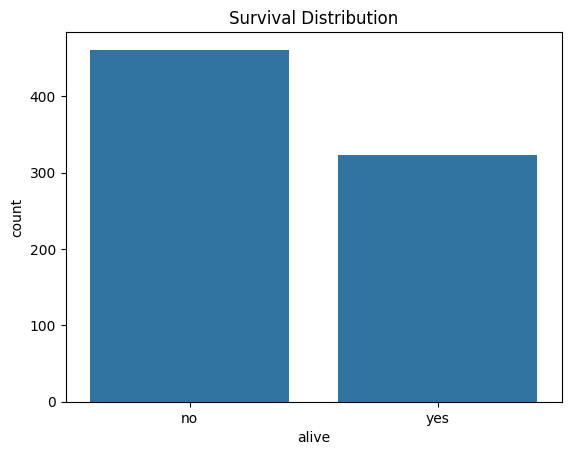

In [ ]:
sns.countplot(data=df, x="alive")
plt.title("Survival Distribution")
plt.show()

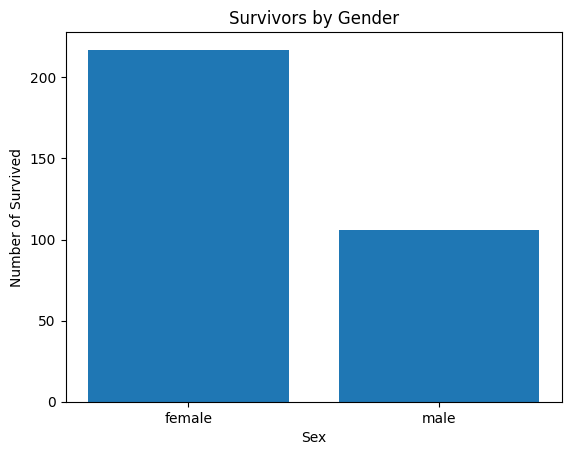

In [ ]:
survived_by_sex = df.groupby("sex")["survived"].sum()
plt.bar(survived_by_sex .index, survived_by_sex .values)
plt.xlabel("Sex")
plt.ylabel("Number of Survived")
plt.title("Survivors by Gender")
plt.show()

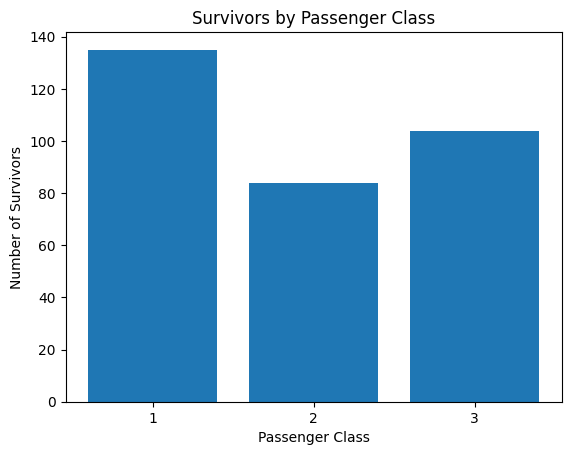

In [ ]:
survival_by_class = df.groupby("pclass")["survived"].sum()
plt.bar(survival_by_class.index, survival_by_class.values)
plt.xlabel("Passenger Class")
plt.ylabel("Number of Survivors")
plt.title("Survivors by Passenger Class")
plt.xticks([1, 2, 3])
plt.show()

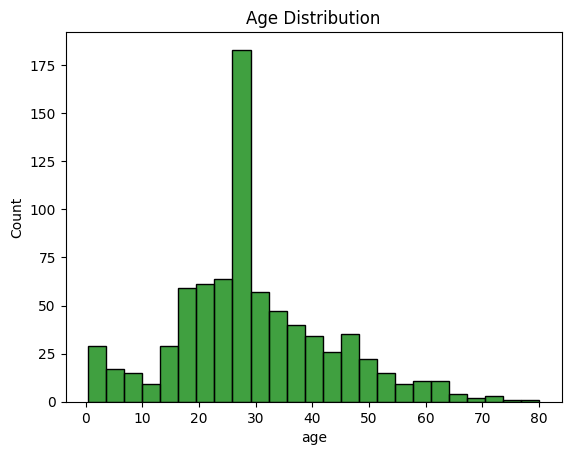

In [ ]:
sns.histplot(data=df, x="age", bins=25,color='green')
plt.title("Age Distribution")
plt.show()

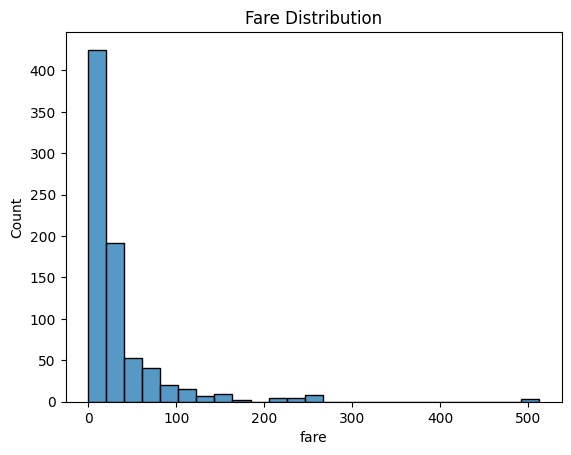

In [ ]:
sns.histplot(data=df, x="fare", bins=25)
plt.title("Fare Distribution")
plt.show()

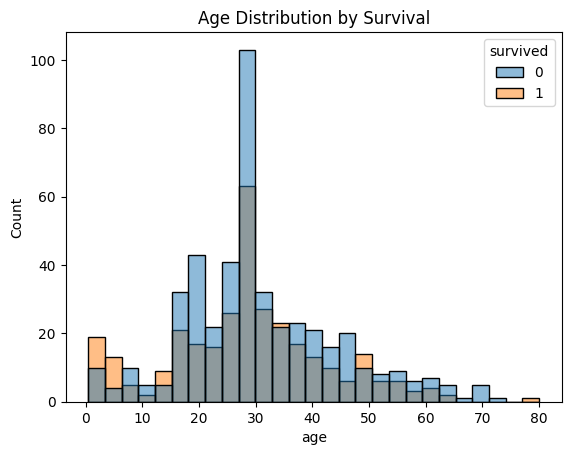

In [ ]:
sns.histplot(data=df, x="age", hue="survived")
plt.title("Age Distribution by Survival")
plt.show()

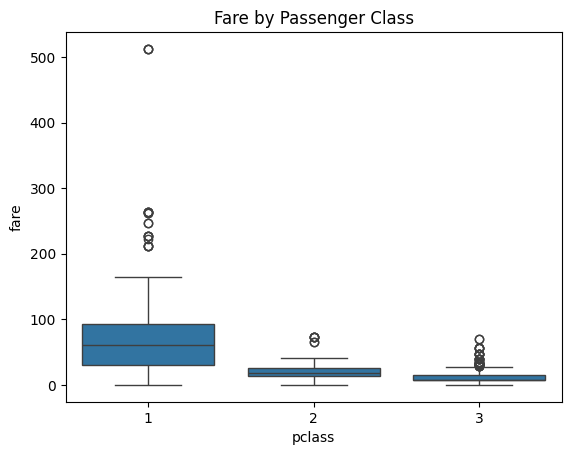

In [ ]:
sns.boxplot(data=df, x="pclass", y="fare")
plt.title("Fare by Passenger Class")
plt.show()

#Correlation Analysis

In [ ]:
correlation = df.corr(numeric_only=True)
correlation

,survived,pclass,age,sibsp,parch,fare,adult_male,alone
survived,1.000000,-0.332658,-0.079184,-0.036589,0.070307,0.246769,-0.528502,-0.176595
pclass,-0.332658,1.000000,-0.342986,0.088014,0.040296,-0.549216,0.066816,0.109545
age,-0.079184,-0.342986,1.000000,-0.279431,-0.183777,0.091315,0.273607,0.191706
sibsp,-0.036589,0.088014,-0.279431,1.000000,0.381433,0.135147,-0.274521,-0.609502
parch,0.070307,0.040296,-0.183777,0.381433,1.000000,0.191942,-0.347186,-0.571087
fare,0.246769,-0.549216,0.091315,0.135147,0.191942,1.000000,-0.165209,-0.246619
adult_male,-0.528502,0.066816,0.273607,-0.274521,-0.347186,-0.165209,1.000000,0.387850
alone,-0.176595,0.109545,0.191706,-0.609502,-0.571087,-0.246619,0.387850,1.000000


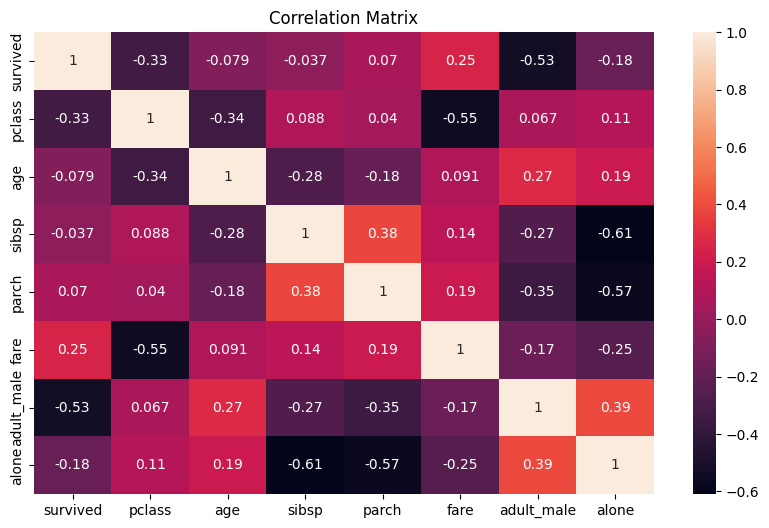

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(correlation, annot=True)
plt.title("Correlation Matrix")
plt.show()

# data summary




1.   most passengers died
2.   Females survived more than men
3.   class 3 had highest number of survived passengers then class 2 then class 1
4. most of the passengers were adults over the age of 25
5.   most of the ticket prices were low.






#Logistic Regression

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.metrics import accuracy_score

In [ ]:
y = df["survived"]

In [ ]:
model_df = df.copy()

In [ ]:
model_df = model_df.drop(columns=["survived", "alive", "class", "who", "embark_town"])

In [ ]:
X = pd.get_dummies(model_df, drop_first=True)

In [ ]:
print(X.head())
print(y.head())

   pclass   age  sibsp  parch     fare  adult_male  alone  sex_male  \
0       3  22.0      1      0   7.2500        True  False      True   
1       1  38.0      1      0  71.2833       False  False     False   
2       3  26.0      0      0   7.9250       False   True     False   
3       1  35.0      1      0  53.1000       False  False     False   
4       3  35.0      0      0   8.0500        True   True      True   

   embarked_Q  embarked_S  
0       False        True  
1       False       False  
2       False        True  
3       False        True  
4       False        True  
0    0
1    1
2    1
3    1
4    0
Name: survived, dtype: int64


# Initialize and train logistic regression model

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [ ]:
logreg = LogisticRegression(max_iter=1000)

In [ ]:
logreg.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = logreg.predict(X_test)

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.86      0.86       139
           1       0.80      0.79      0.80        97

    accuracy                           0.83       236
   macro avg       0.83      0.83      0.83       236
weighted avg       0.83      0.83      0.83       236



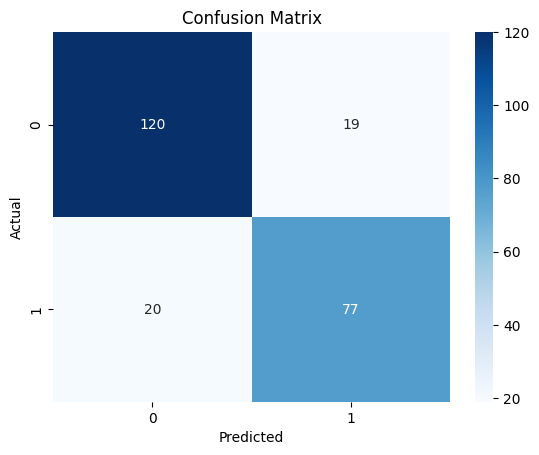

In [ ]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

#Accuracy

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8347457627118644


#Prediction

In [ ]:
y_pred_proba = logreg.predict_proba(X_test)

In [ ]:
y_pred_proba = logreg.predict_proba(X_test)[:, 1]

#ROC Curve + AUC

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

In [ ]:
auc = roc_auc_score(y_test, y_pred_proba)

print("AUC:", auc)

AUC: 0.8996514128903064


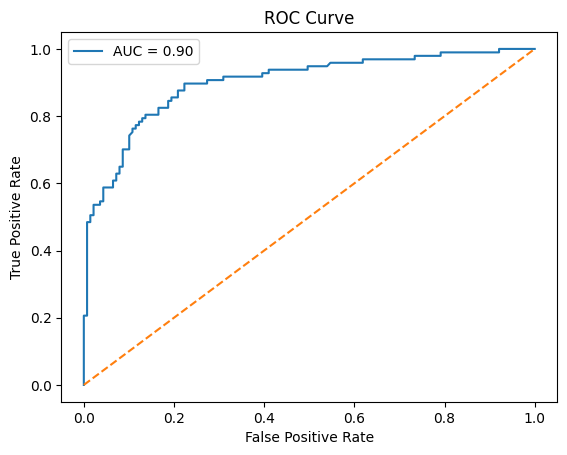

In [ ]:
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()